/tmp/ipykernel_3149813/3910279366.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[t] = H @ x_prev + np.random.normal(0, np.sqrt(obs_var))
/tmp/ipykernel_3149813/3910279366.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fitted_obs[t] = H @ m_t


Mean entropy reduction per step: 0.445
Entropy reductions (first 10): [0.159 0.273 0.369 0.408 0.414 0.412 0.414 0.419 0.424 0.427]


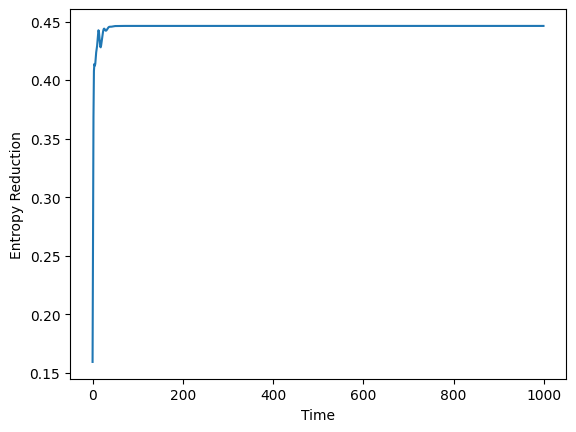

In [25]:
import numpy as np

np.random.seed(42)

# Model dimensions and parameters
T = 1000            # Number of time points
S = 12             # Period of seasonality (e.g., 12 months)
omega = 2 * np.pi / S

# State: [mu, beta, s, s_lag]
q = 4

# System matrices
F = np.array([
    [1, 1, 0, 0],
    [0, 1, 0, 0],
    [0, 0, np.cos(omega), np.sin(omega)],
    [0, 0, -np.sin(omega), np.cos(omega)]
])

H = np.array([[1, 0, 1, 0]])  # y_t = mu_t + s_t + noise

# Process and observation noise
delta = 0.8   # Adjust as desired (0 < delta < 1)
obs_var = 1.0  # Constant observation variance

# Initial state and covariance
x0 = np.array([0, 0, 1, 0])
C0 = np.eye(q) * 0.1

# Storage
states = np.zeros((T, q))
y = np.zeros(T)

# Simulate states and observations
x_prev = x0.copy()
states[0, :] = x_prev
for t in range(T):
    if t > 0:
        x_prev = F @ x_prev + np.random.multivariate_normal(np.zeros(q), np.eye(q)*0.1)
        states[t, :] = x_prev
    y[t] = H @ x_prev + np.random.normal(0, np.sqrt(obs_var))

# ---- Kalman filter ----
P = np.zeros((q, q, T))
R = np.zeros((q, q, T))
C = np.zeros((q, q, T))
entropy_reduction = np.zeros(T)

C_prev = C0.copy()
m_prev = x0.copy()

filtered_means = np.zeros((T, q))
fitted_obs = np.zeros(T)

for t in range(T):
    # 1. Predict
    P_t = F @ C_prev @ F.T
    W_t = (1/delta - 1) * P_t
    R_t = P_t + W_t  # or equivalently: R_t = P_t / delta
    
    # 2. Update
    S_t = H @ R_t @ H.T + obs_var
    K_t = R_t @ H.T / S_t  # Shape: (q, 1)
    innov = y[t] - (H @ (F @ m_prev))  # innovation using predicted mean

    m_t = F @ m_prev + (K_t.flatten() * innov)
    C_t = (np.eye(q) - K_t @ H) @ R_t

    # 3. Store
    P[:, :, t] = P_t
    R[:, :, t] = R_t
    C[:, :, t] = C_t

    # 4. Entropy reduction (log determinant ratio)
    entropy_reduction[t] = 0.5 * np.log(np.linalg.det(R_t) / np.linalg.det(C_t))

    # Prepare for next
    C_prev = C_t
    m_prev = m_t

    # Save filtered state mean and fitted value
    filtered_means[t, :] = m_t
    fitted_obs[t] = H @ m_t


print(f"Mean entropy reduction per step: {np.mean(entropy_reduction):.3f}")
print("Entropy reductions (first 10):", np.round(entropy_reduction[:10], 3))


In [ ]:

import matplotlib.pyplot as plt
plt.plot(entropy_reduction)
plt.ylabel("Entropy Reduction")
plt.xlabel("Time")
plt.show()


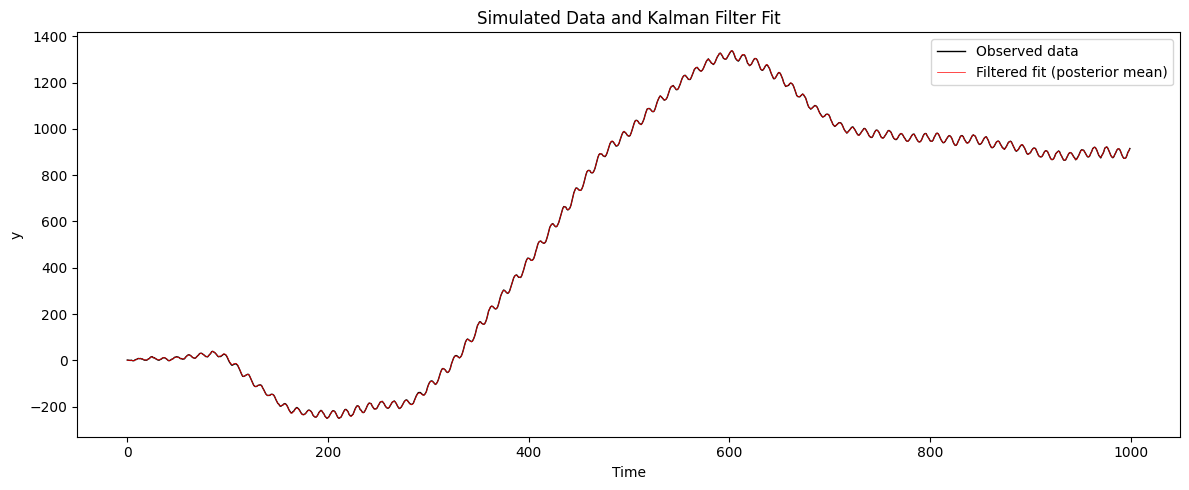

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y, label='Observed data', color='black', linewidth=1)
plt.plot(fitted_obs, label='Filtered fit (posterior mean)', color='red', linewidth=0.5)

plt.xlabel('Time')
plt.ylabel('y')
plt.legend()
plt.title('Simulated Data and Kalman Filter Fit')
plt.tight_layout()
plt.show()


/tmp/ipykernel_3149813/1300323107.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[t] = H @ x_prev + np.random.normal(0, np.sqrt(obs_var))


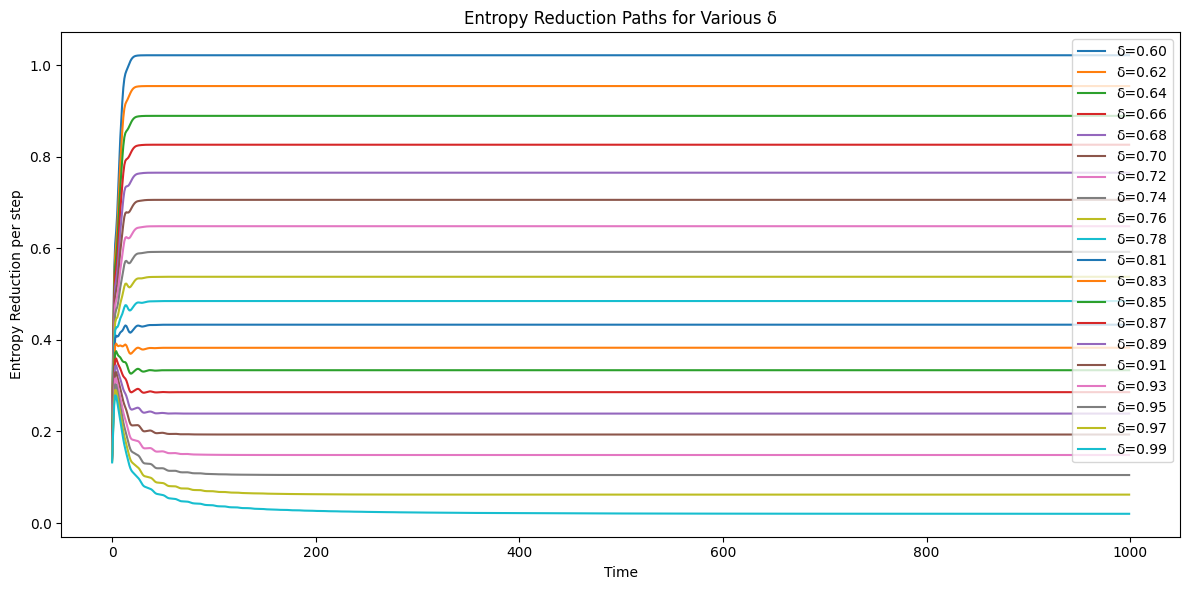

In [35]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Model dimensions and parameters
T = 1000            # Number of time points
S = 12             # Period of seasonality (e.g., 12 months)
omega = 2 * np.pi / S
q = 4

# System matrices
F = np.array([
    [1, 1, 0, 0],
    [0, 1, 0, 0],
    [0, 0, np.cos(omega), np.sin(omega)],
    [0, 0, -np.sin(omega), np.cos(omega)]
])
H = np.array([[1, 0, 1, 0]])  # y_t = mu_t + s_t + noise

obs_var = 1.0  # Constant observation variance

# Initial state and covariance
x0 = np.array([0, 0, 1, 0])
C0 = np.eye(q) * 0.1

# ---- Simulate one state/observation sequence for fairness ----
states = np.zeros((T, q))
y = np.zeros(T)

x_prev = x0.copy()
states[0, :] = x_prev
for t in range(T):
    if t > 0:
        x_prev = F @ x_prev + np.random.multivariate_normal(np.zeros(q), np.eye(q)*0.5)
        states[t, :] = x_prev
    y[t] = H @ x_prev + np.random.normal(0, np.sqrt(obs_var))

# ---- Try different delta values ----
deltas = np.linspace(0.6, 0.99, 20)  # e.g., 0.6, 0.66, ..., 0.99
entropy_reductions_all = []

for delta in deltas:
    C_prev = C0.copy()
    m_prev = x0.copy()
    entropy_reduction = np.zeros(T)

    for t in range(T):
        # 1. Predict
        P_t = F @ C_prev @ F.T
        W_t = (1/delta - 1) * P_t
        R_t = P_t + W_t  # or equivalently: R_t = P_t / delta

        # 2. Update
        S_t = H @ R_t @ H.T + obs_var
        K_t = R_t @ H.T / S_t  # Shape: (q, 1)
        innov = y[t] - (H @ (F @ m_prev))

        m_t = F @ m_prev + (K_t.flatten() * innov)
        C_t = (np.eye(q) - K_t @ H) @ R_t

        # Entropy reduction (log determinant ratio)
        entropy_reduction[t] = 0.5 * np.log(np.linalg.det(R_t) / np.linalg.det(C_t))

        # Prepare for next
        C_prev = C_t
        m_prev = m_t

    entropy_reductions_all.append(entropy_reduction)

# ---- Plot all entropy reduction paths ----
plt.figure(figsize=(12, 6))
for i, delta in enumerate(deltas):
    plt.plot(entropy_reductions_all[i], label=f'δ={delta:.2f}')
plt.xlabel("Time")
plt.ylabel("Entropy Reduction per step")
plt.title("Entropy Reduction Paths for Various δ")
plt.legend()
plt.tight_layout()
plt.show()


In [36]:
from scipy.optimize import minimize_scalar

def kalman_loglikelihood(y, F, H, obs_var, x0, C0, delta):
    T = len(y)
    q = F.shape[0]
    loglik = 0.0
    m_prev = x0.copy()
    C_prev = C0.copy()
    for t in range(T):
        P_t = F @ C_prev @ F.T
        W_t = (1/delta - 1) * P_t
        R_t = P_t + W_t
        S_t = H @ R_t @ H.T + obs_var
        # Predictive log-likelihood for y_t | y_{1:t-1}
        innov = y[t] - (H @ (F @ m_prev))
        loglik += -0.5 * (np.log(S_t) + (innov**2)/S_t + np.log(2*np.pi))
        K_t = R_t @ H.T / S_t
        m_t = F @ m_prev + (K_t.flatten() * innov)
        C_t = (np.eye(q) - K_t @ H) @ R_t
        m_prev = m_t
        C_prev = C_t
    return -loglik  # Negative for minimization

# Optimize delta on a simulated dataset
res = minimize_scalar(
    lambda d: kalman_loglikelihood(y, F, H, obs_var, x0, C0, d),
    bounds=(0.6, 0.99), method='bounded'ta_learning
)
delta_best = res.x
print("Best delta (MLE):", delta_best)


Best delta (MLE): [[0.62118842]]


/tmp/ipykernel_3150455/3263004543.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[t] = H @ x_prev + np.random.normal(0, np.sqrt(obs_var))


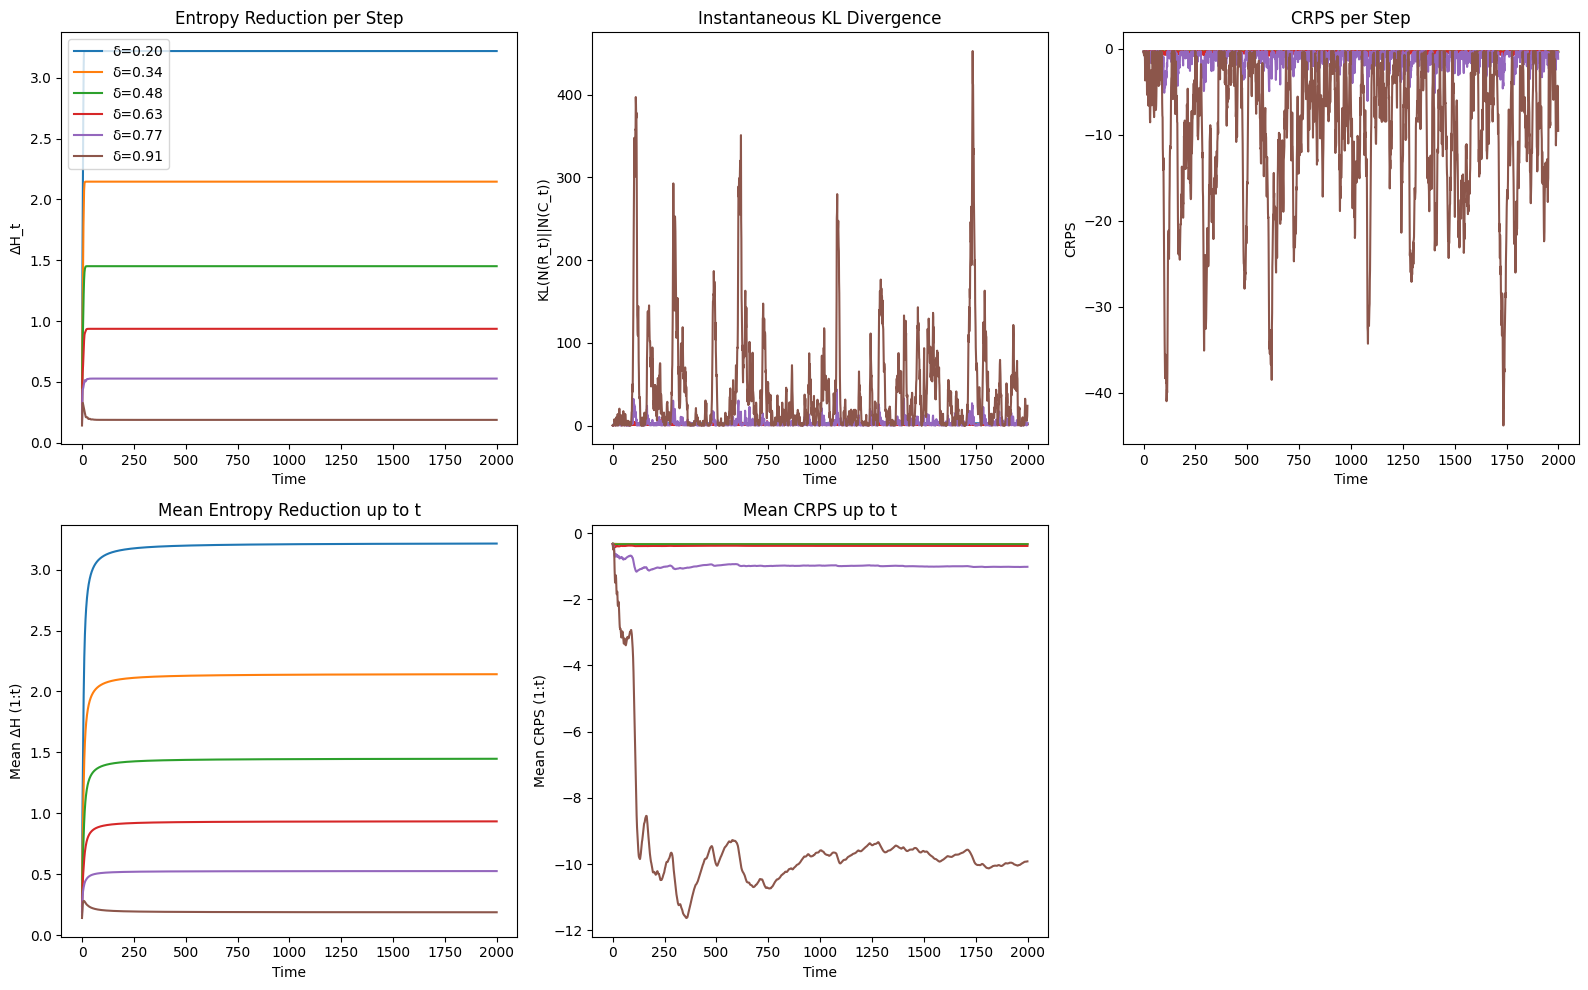

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

T = 2000
S = 12
omega = 2 * np.pi / S
q = 4

F = np.array([
    [1, 1, 0, 0],
    [0, 1, 0, 0],
    [0, 0, np.cos(omega), np.sin(omega)],
    [0, 0, -np.sin(omega), np.cos(omega)]
])
H = np.array([[1, 0, 1, 0]])
obs_var = 1.0

x0 = np.array([0, 0, 1, 0])
C0 = np.eye(q) * 0.1

states = np.zeros((T, q))
y = np.zeros(T)
x_prev = x0.copy()
states[0, :] = x_prev
for t in range(T):
    if t > 0:
        x_prev = F @ x_prev + np.random.multivariate_normal(np.zeros(q), np.eye(q)*1)
        states[t, :] = x_prev
    y[t] = H @ x_prev + np.random.normal(0, np.sqrt(obs_var))

deltas = np.linspace(0.2, 0.91, 6)

all_entropy = []
all_kl = []
all_crps = []
all_mean_crps = []
all_mean_entropy = []

def crps_gaussian(mu, sigma, y_obs):
    z = (y_obs - mu) / sigma
    return sigma * (1/np.sqrt(np.pi) - 2 * norm.pdf(z) - z * (2 * norm.cdf(z) - 1))

for delta in deltas:
    C_prev = C0.copy()
    m_prev = x0.copy()
    entropy_reduction = np.zeros(T)
    kl_div = np.zeros(T)
    crps = np.zeros(T)
    mean_crps = np.zeros(T)
    mean_entropy = np.zeros(T)

    for t in range(T):
        # Predict
        P_t = F @ C_prev @ F.T
        W_t = (1/delta - 1) * P_t
        R_t = P_t + W_t

        # Update
        S_t = H @ R_t @ H.T + obs_var
        K_t = R_t @ H.T / S_t
        innov = y[t] - (H @ (F @ m_prev))
        m_pred = F @ m_prev
        m_t = m_pred + (K_t.flatten() * innov)
        C_t = (np.eye(q) - K_t @ H) @ R_t

        # 1. Entropy reduction
        entropy_reduction[t] = 0.5 * np.log(np.linalg.det(R_t) / np.linalg.det(C_t))

        # 2. Instantaneous KL
        delta_m = (m_pred - m_t)
        kl = 0.5 * (
            np.log(np.linalg.det(R_t) / np.linalg.det(C_t))
            - q
            + np.trace(np.linalg.solve(R_t, C_t))
            + delta_m @ np.linalg.solve(R_t, delta_m)
        )
        kl_div[t] = kl

        # 3. CRPS
        mu_pred = H @ m_t
        var_pred = H @ C_t @ H.T + obs_var
        sigma_pred = np.sqrt(var_pred.item())
        crps[t] = crps_gaussian(mu_pred.item(), sigma_pred, y[t])

        # 4. Mean metrics up to t
        mean_crps[t] = np.mean(crps[:t+1])
        mean_entropy[t] = np.mean(entropy_reduction[:t+1])

        # Prepare for next
        C_prev = C_t
        m_prev = m_t

    all_entropy.append(entropy_reduction)
    all_kl.append(kl_div)
    all_crps.append(crps)
    all_mean_crps.append(mean_crps)
    all_mean_entropy.append(mean_entropy)

times = np.arange(T)
labels = [f'δ={d:.2f}' for d in deltas]

plt.figure(figsize=(16, 10))

plt.subplot(2,3,1)
for entropy, lbl in zip(all_entropy, labels):
    plt.plot(times, entropy, label=lbl)
plt.title('Entropy Reduction per Step')
plt.xlabel('Time'); plt.ylabel('ΔH_t')
plt.legend()

plt.subplot(2,3,2)
for kl, lbl in zip(all_kl, labels):
    plt.plot(times, kl, label=lbl)
plt.title('Instantaneous KL Divergence')
plt.xlabel('Time'); plt.ylabel('KL(N(R_t)||N(C_t))')

plt.subplot(2,3,3)
for crps, lbl in zip(all_crps, labels):
    plt.plot(times, crps, label=lbl)
plt.title('CRPS per Step')
plt.xlabel('Time'); plt.ylabel('CRPS')

plt.subplot(2,3,4)
for mean_entropy, lbl in zip(all_mean_entropy, labels):
    plt.plot(times, mean_entropy, label=lbl)
plt.title('Mean Entropy Reduction up to t')
plt.xlabel('Time'); plt.ylabel('Mean ΔH (1:t)')

plt.subplot(2,3,5)
for mean_crps, lbl in zip(all_mean_crps, labels):
    plt.plot(times, mean_crps, label=lbl)
plt.title('Mean CRPS up to t')
plt.xlabel('Time'); plt.ylabel('Mean CRPS (1:t)')

plt.tight_layout()
plt.show()


In [16]:
final_mean_crps = [mean_crps[-1] for mean_crps in all_mean_crps]
best_idx = np.argmin(final_mean_crps)
best_delta = deltas[best_idx]
print(f"Best δ by mean CRPS: {best_delta:.3f}")


Best δ by mean CRPS: 0.910


/tmp/ipykernel_3150455/338498551.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[t] = H @ x_prev + np.random.normal(0, np.sqrt(obs_var))
/tmp/ipykernel_3150455/338498551.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fitted_obs[t] = H @ m_t


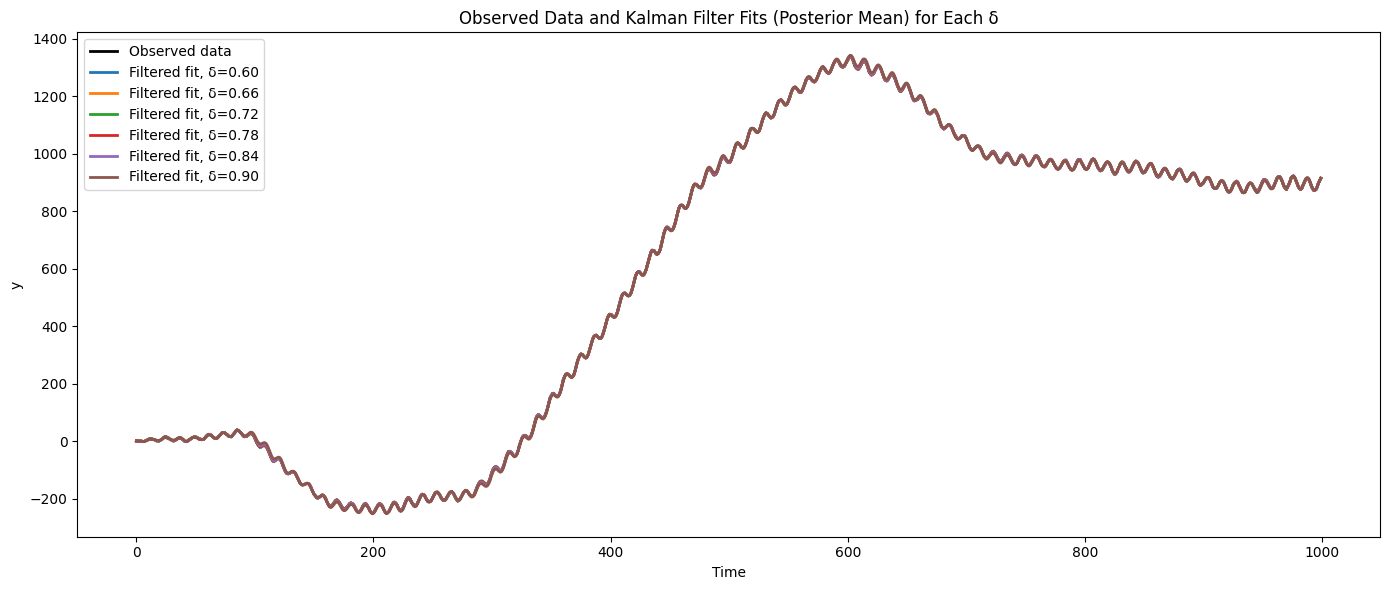

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

T = 1000
S = 12
omega = 2 * np.pi / S
q = 4

F = np.array([
    [1, 1, 0, 0],
    [0, 1, 0, 0],
    [0, 0, np.cos(omega), np.sin(omega)],
    [0, 0, -np.sin(omega), np.cos(omega)]
])
H = np.array([[1, 0, 1, 0]])
obs_var = 1.0

x0 = np.array([0, 0, 1, 0])
C0 = np.eye(q) * 0.1

states = np.zeros((T, q))
y = np.zeros(T)
x_prev = x0.copy()
states[0, :] = x_prev
for t in range(T):
    if t > 0:
        x_prev = F @ x_prev + np.random.multivariate_normal(np.zeros(q), np.eye(q)*0.1)
        states[t, :] = x_prev
    y[t] = H @ x_prev + np.random.normal(0, np.sqrt(obs_var))

deltas = np.linspace(0.6, 0.9, 6)
fit_all = []

def crps_gaussian(mu, sigma, y_obs):
    z = (y_obs - mu) / sigma
    return sigma * (1/np.sqrt(np.pi) - 2 * norm.pdf(z) - z * (2 * norm.cdf(z) - 1))

for delta in deltas:
    C_prev = C0.copy()
    m_prev = x0.copy()
    fitted_obs = np.zeros(T)

    for t in range(T):
        # Predict
        P_t = F @ C_prev @ F.T
        W_t = (1/delta - 1) * P_t
        R_t = P_t + W_t

        # Update
        S_t = H @ R_t @ H.T + obs_var
        K_t = R_t @ H.T / S_t
        innov = y[t] - (H @ (F @ m_prev))
        m_pred = F @ m_prev
        m_t = m_pred + (K_t.flatten() * innov)
        C_t = (np.eye(q) - K_t @ H) @ R_t

        # Fitted value for plotting
        fitted_obs[t] = H @ m_t

        # Prepare for next
        C_prev = C_t
        m_prev = m_t

    fit_all.append(fitted_obs)

# PLOT
plt.figure(figsize=(14,6))
plt.plot(y, label='Observed data', color='black', linewidth=2)
for fit, delta in zip(fit_all, deltas):
    plt.plot(fit, label=f'Filtered fit, δ={delta:.2f}', linewidth=2)
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Observed Data and Kalman Filter Fits (Posterior Mean) for Each δ')
plt.legend()
plt.tight_layout()
plt.show()
